# Parametric Value at Risk

This notebook estimates portfolio Value at Risk using a parametric approach based on the normal distribution.

Unlike Historical VaR, which uses the empirical distribution of observed portfolio returns, Parametric VaR assumes that portfolio returns follow a specified probability distribution.

The initial model assumes normally distributed returns and estimates portfolio volatility from the covariance matrix of asset returns.

The analysis covers:

1. Normal-distribution assumption
2. Portfolio volatility
3. Parametric VaR at 95% confidence
4. Parametric VaR at 99% confidence
5. Monetary VaR
6. Comparison with Historical VaR
7. Assessment of the normality assumption

In [33]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from project_01_market_risk_engine.src.data import download_prices

In [34]:
TICKERS = [
    "SPY",
    "QQQ",
    "IWM",
    "TLT",
    "GLD"
]

weights = pd.Series({
    "SPY": 0.30,
    "QQQ": 0.20,
    "IWM": 0.15,
    "TLT": 0.20,
    "GLD": 0.15
})

prices = download_prices(
    tickers=TICKERS,
    start="2015-01-01",
    end="2026-01-01"
)

returns = prices.pct_change().dropna()

portfolio_returns = returns @ weights

[*********************100%***********************]  5 of 5 completed


In [35]:
daily_covariance = returns.cov()
annualized_covariance = daily_covariance * 252
portfolio_annualized_volatility = np.sqrt(weights.T @ annualized_covariance @ weights)
portfolio_daily_volatility = portfolio_annualized_volatility / np.sqrt(252)

## Normal Distribution Assumption

Parametric VaR assumes that portfolio returns can be represented by a normal distribution characterized by a mean and standard deviation.

For the initial model, portfolio volatility is estimated using the covariance matrix of the asset returns.

The normal distribution assumption is a simplifying assumption and will be evaluated against the empirical return distribution and Historical VaR.

For a confidence level $c$, the parametric VaR is calculated as:

$$
\text{VaR}_c = -(\mu_p + z_{1-c}\sigma_p)
$$

where:

- $\mu_p$ = mean daily portfolio return
- $\sigma_p$ = daily portfolio volatility
- $z_{1-c}$ = standard normal quantile corresponding to the loss tail

In [36]:
portfolio_mean = portfolio_returns.mean()
print(f"Mean daily return: {portfolio_mean:.6%}")
print(f"Daily volatility: {portfolio_daily_volatility:.6%}")

Mean daily return: 0.046315%
Daily volatility: 0.808991%


## Parametric VaR Calculation

The standard normal quantile is used to determine the return threshold corresponding to each confidence level.

At 95% confidence, the lower-tail z-score is approximately -1.645.

At 99% confidence, the lower-tail z-score is approximately -2.326.

The resulting threshold is converted into a positive loss measure for conventional VaR reporting.

In [37]:
confidence_interval = 0.95
z_score = norm.ppf(1-confidence_interval)
z_score

np.float64(-1.6448536269514722)

### 95% VaR

At the 95% confidence level, the model estimates a one-day Parametric VaR of approximately 1.284%.

For a $100,000 portfolio, this corresponds to an estimated one-day loss threshold of approximately $1,284.

In [38]:
var_95_return = -(portfolio_mean + z_score*portfolio_daily_volatility)
var_95_return

np.float64(0.012843574147369823)

### 99% VaR

At the 99% confidence level, the model estimates a one-day Parametric VaR of approximately 1.836%.

For a $100,000 portfolio, this corresponds to an estimated one-day loss threshold of approximately $1,836.

The increase from the 95% to 99% threshold reflects the progressively more extreme tail of the assumed normal distribution.

In [39]:

confidence_interval = 0.99
z_score = norm.ppf(1-confidence_interval)
var_99_return = -(portfolio_mean + z_score*portfolio_daily_volatility)
var_99_return

np.float64(0.018356803257512228)

In [40]:
parametric_var_table = pd.DataFrame({
    "Confidence Interval": ['95%', '99%'],
    "z-score" : [norm.ppf(0.05), norm.ppf(0.01)],
    "VaR Return":[var_95_return, var_99_return]
})
parametric_var_table

,Confidence Interval,z-score,VaR Return
0,95%,-1.644854,0.012844
1,99%,-2.326348,0.018357


### Convert to Dollars

The percentage VaR estimates are converted into monetary terms using a hypothetical portfolio value of $100,000.

This allows the model outputs to be interpreted directly as estimated one-day portfolio losses.

In [41]:
portfolio_value = 100_000

var_95_dollars = var_95_return * portfolio_value
var_99_dollars = var_99_return * portfolio_value

print(f"95% Parametric VaR: ${var_95_dollars:,.2f}")
print(f"99% Parametric VaR: ${var_99_dollars:,.2f}")

95% Parametric VaR: $1,284.36
99% Parametric VaR: $1,835.68


## Parametric VaR vs. Empirical Returns

The empirical distribution of portfolio returns is compared with the fitted normal distribution used by the Parametric VaR model.

The 95% and 99% VaR thresholds are shown on the distribution to illustrate how the normality assumption determines the estimated tail losses.

The comparison also provides a visual assessment of the extent to which the normal distribution represents the observed return distribution.

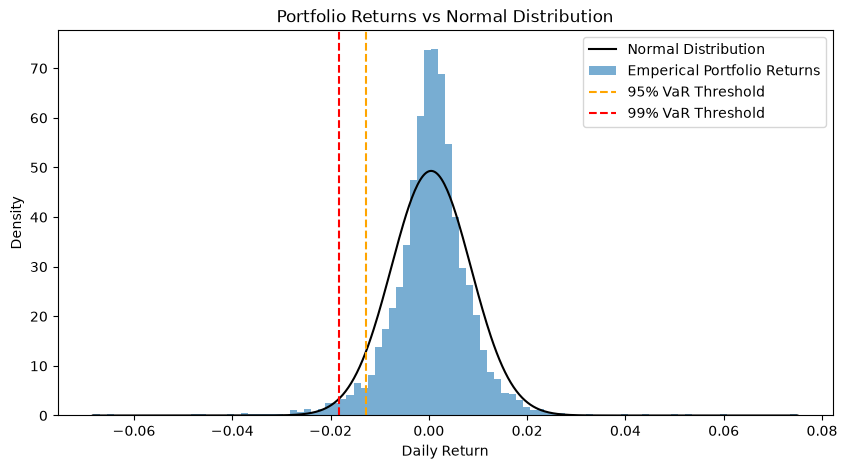

In [42]:
x = np.linspace(portfolio_returns.min(), portfolio_returns.max(), num=500)

normal_density = norm.pdf(x,portfolio_mean, portfolio_daily_volatility)

plt.figure(figsize = (10,5))
plt.plot(
    x,
    normal_density,
    color = "black",
    label = "Normal Distribution"
)

plt.hist(
    portfolio_returns,
    bins = 100,
    density=True,
    alpha = .6,
    label = "Emperical Portfolio Returns"
)

plt.axvline(
    -var_95_return,
    linestyle="--",
    color = "orange",
    label = "95% VaR Threshold"
)

plt.axvline(
    -var_99_return,
    linestyle="--",
    color = "red",
    label = "99% VaR Threshold"
)

plt.title("Portfolio Returns vs Normal Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()

plt.show()


## Comparison with Historical VaR

Historical VaR and Parametric VaR use different approaches to estimate tail risk.

**Historical VaR** uses the empirical distribution of observed portfolio returns and therefore retains the historical shape of the return distribution.

**Parametric VaR** assumes a normal distribution and summarizes portfolio risk using the estimated mean and volatility.

Comparing the two methods allows the impact of the normality assumption to be evaluated directly.

In [ ]:
import project_01_market_risk_engine.src.var as a

historical_var_95 = a.historical_var(
    portfolio_returns,
    confidence_level=0.95
)

historical_var_99 = a.historical_var(
    portfolio_returns,
    confidence_level=0.99
)

var_95_return = a.parametric_var(
    portfolio_returns,
    confidence_level= 0.95
)

var_99_return = a.parametric_var(
    portfolio_returns,
    confidence_level=0.99
)

var_comparison = pd.DataFrame({
    "Confidence Level" : ["95%", "99%"],
    "Historical VaR" : [historical_var_95, historical_var_99],
    "Parametric VaR" : [var_95_return, var_99_return]
})

var_comparison["Difference"] = (
    var_comparison["Parametric VaR"]
    - var_comparison["Historical VaR"]
)

var_comparison["Difference (%)"] = (
    var_comparison["Difference"]
    / var_comparison["Historical VaR"]
    * 100
)


['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'historical_expected_shortfall', 'historical_var', 'norm', 'parametric_var', 'pd']


In [46]:
var_comparison

,Confidence Level,Historical VaR,Parametric VaR,Difference,Difference (%)
0,95%,0.011848,0.012844,0.000996,8.406423
1,99%,0.021801,0.018357,-0.003445,-15.800083


### Key Observation

Parametric VaR is higher than Historical VaR at the 95% confidence level but materially lower at the 99% confidence level.

At 95% confidence, Parametric VaR is approximately 8.4% higher than Historical VaR. At 99% confidence, it is approximately 15.8% lower.

The lower 99% Parametric VaR indicates that the normal distribution does not fully capture the severity of the observed historical left tail. This is consistent with the non-normality observed in the return distributions.

The comparison demonstrates why relying on a single distributional assumption can materially affect extreme-tail risk estimates.